# CanadaWildFireDaily: Representative Sample Analysis

This notebook visualizes a representative sample from our dataset (Fire ID: `2024_188`). It breaks down the HDF5 file structure, visualizes the raw input bands for a specific day, and analyzes the final numpy arrays used for model training.x

### How the H5 file Was Created
To create the standardized inputs for our deep learning models, raw data from multiple sources was unified into a common spatial and temporal grid:
1. **Topography & Vegetation (Static):** Digital Elevation Model (DEM) data from ASTER GDEM V3 and forest vegetation attributes from SCANFI v2 were reprojected to EPSG:3347 and downsampled to a 90m resolution using average resampling.
2. **Meteorology (Dynamic):** Hourly ERA5-Land data was aggregated into daily metrics (24-hour max temperature, noon-to-noon cumulative precipitation, and noon wind/humidity) and upsampled to the 90m grid via nearest-neighbor interpolation.
3. **Satellite Imagery (Dynamic):** Sentinel-2 L2A multispectral images and VIIRS (NDVI/EVI) 16-day composites were reprojected to EPSG:3347 and resampled to 90m.
4. **Fire Masks (Target):** Active fire perimeters were rasterized from the Canadian Fire Spread Dataset (CFSDS). The current day's burn area dictates the fire state.

These aligned variables are grouped into spatial tiles (256 x 256 pixels) and saved locally as HDF5 files.

# Setup

In [35]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
DATA_FOLDER = './Data'
fire_id = '2024_188'
h5_path = f'{DATA_FOLDER}/fire_{fire_id}.h5' 
tile_id = 'tile_189_127'
day_key = 'day_006'

# H5 Fire Data

## H5 File Structure

In [38]:
# Print File Structure & Metadata
def print_h5_tree_filtered(val, target_tile, target_day, pre=''):
    """Recursively prints the HDF5 structure, collapsing non-target tiles and days."""
    name = val.name.split('/')[-1]
    
    if isinstance(val, h5py.Dataset):
        print(f"{pre}📄 {name} (Shape: {val.shape}, Type: {val.dtype})")
    elif isinstance(val, h5py.Group):
        folder_name = name if name else "/"
        
        # Collapse non-target tiles
        if folder_name.startswith('tile_') and folder_name != target_tile:
            print(f"{pre}📁 {folder_name}/  ... (contents collapsed)")
            return
            
        # Collapse non-target days
        if folder_name.startswith('day_') and folder_name != target_day:
            print(f"{pre}📁 {folder_name}/  ... (contents collapsed)")
            return

        # Print the current folder
        print(f"{pre}📁 {folder_name}/")
        if (folder_name == 'satellite' or folder_name.startswith('day_')) and val.attrs:
            for attr_key, attr_val in val.attrs.items():
                print(f"{pre}  🏷️ {attr_key}: {attr_val}")
        for key in val.keys():
            print_h5_tree_filtered(val[key], target_tile, target_day, pre + '  ')

In [39]:
with h5py.File(h5_path, 'r') as f:
    print("--- GLOBAL METADATA ---")
    for k, v in f.attrs.items():
        print(f"{k}: {v}")
    
    print("\n--- H5 FILE STRUCTURE ---")
    print_h5_tree_filtered(f, tile_id, day_key)

--- GLOBAL METADATA ---
deg_crs: EPSG:4269
fire_id: 2024_188
meter_crs: EPSG:3347
pixel_size: 90
year: 2024

--- H5 FILE STRUCTURE ---
📁 //
  📁 tile_188_127/  ... (contents collapsed)
  📁 tile_189_127/
    📁 coords/
      📄 theoretical_easting (Shape: (256, 256), Type: int64)
      📄 theoretical_lat (Shape: (256, 256), Type: float64)
      📄 theoretical_lon (Shape: (256, 256), Type: float64)
      📄 theoretical_northing (Shape: (256, 256), Type: int64)
    📁 days/
      📁 day_001/  ... (contents collapsed)
      📁 day_002/  ... (contents collapsed)
      📁 day_003/  ... (contents collapsed)
      📁 day_004/  ... (contents collapsed)
      📁 day_005/  ... (contents collapsed)
      📁 day_006/
        🏷️ DOB: 203
        🏷️ end_utc: 2024-07-22T07:00:00
        🏷️ fireday: 6
        🏷️ month: 7
        🏷️ noon_utc: 2024-07-21T19:00:00
        🏷️ start_utc: 2024-07-21T07:00:00
        📁 features/
          📄 cumuarea (Shape: (256, 256), Type: bool)
          📄 evi (Shape: (256, 256), Type:

## Raw Features Visualization

In [40]:
def visualize_raw_features(h5_path, tile_id, day_key, fire_feat, dynamic_feats, static_feats):
    """
    Reads specific static and dynamic features from the H5 file and plots them in a grid.
    """
    with h5py.File(h5_path, 'r') as f:
        
        all_feats = []

        path = f"{tile_id}/days/{day_key}/features/{fire_feat}"
        if path in f:
            name = "New Fire Growth"
            all_feats.insert(0, (name, path, 'Fire mask'))
        
        # Get dynamic features
        for feat in dynamic_feats:
            if feat.startswith('s2_'):
                path = f"{tile_id}/days/{day_key}/satellite/{feat}"
            else:
                path = f"{tile_id}/days/{day_key}/features/{feat}"
            all_feats.append((feat, path, 'Dynamic'))
            
        # Get static features
        for feat in static_feats:
            path = f"{tile_id}/static_features/{feat}"
            all_feats.append((feat, path, 'Static'))
            
        # Setup the matplotlib grid
        num_plots = len(all_feats)
        cols = 5
        rows = int(np.ceil(num_plots / cols))
        
        fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
        axes = axes.flatten()
        
        print(f"Visualizing Raw Features for {tile_id} -> {day_key}\n")
        
        for i, (feat_name, path, feat_type) in enumerate(all_feats):
            ax = axes[i]
            
            try:
                # Extract the 2D array
                data = f[path][:]
                
                # Assign the colormaps
                cmap = 'viridis'
                if feat_name == 'dem': cmap = 'terrain'
                elif feat_name == 'prec': cmap = 'Blues'
                elif feat_name == 'tmax': cmap = 'coolwarm'
                elif feat_name in ['ndvi', 'evi', 'closure', 'biomass', 'prcc', 'prcb']: cmap = 'YlGn'
                elif feat_name.startswith('s2_'): cmap = 'RdYlGn_r'
                elif 'cumuarea' in path: cmap = 'magma'
                
                im = ax.imshow(data, cmap=cmap)
                ax.set_title(f"{feat_name.upper()} ({feat_type})", fontsize=12, fontweight='bold')
                ax.axis('off')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                
            except KeyError:
                # If a feature is missing in the H5 file, display a blank placeholder
                ax.text(0.5, 0.5, f"{feat_name}\nNot Found", ha='center', va='center', color='red')
                ax.set_title(f"{feat_name.upper()} (MISSING)")
                ax.axis('off')
                
        # Hide any unused subplots at the end of the grid
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
        plt.show()

Visualizing Raw Features for tile_189_127 -> day_006



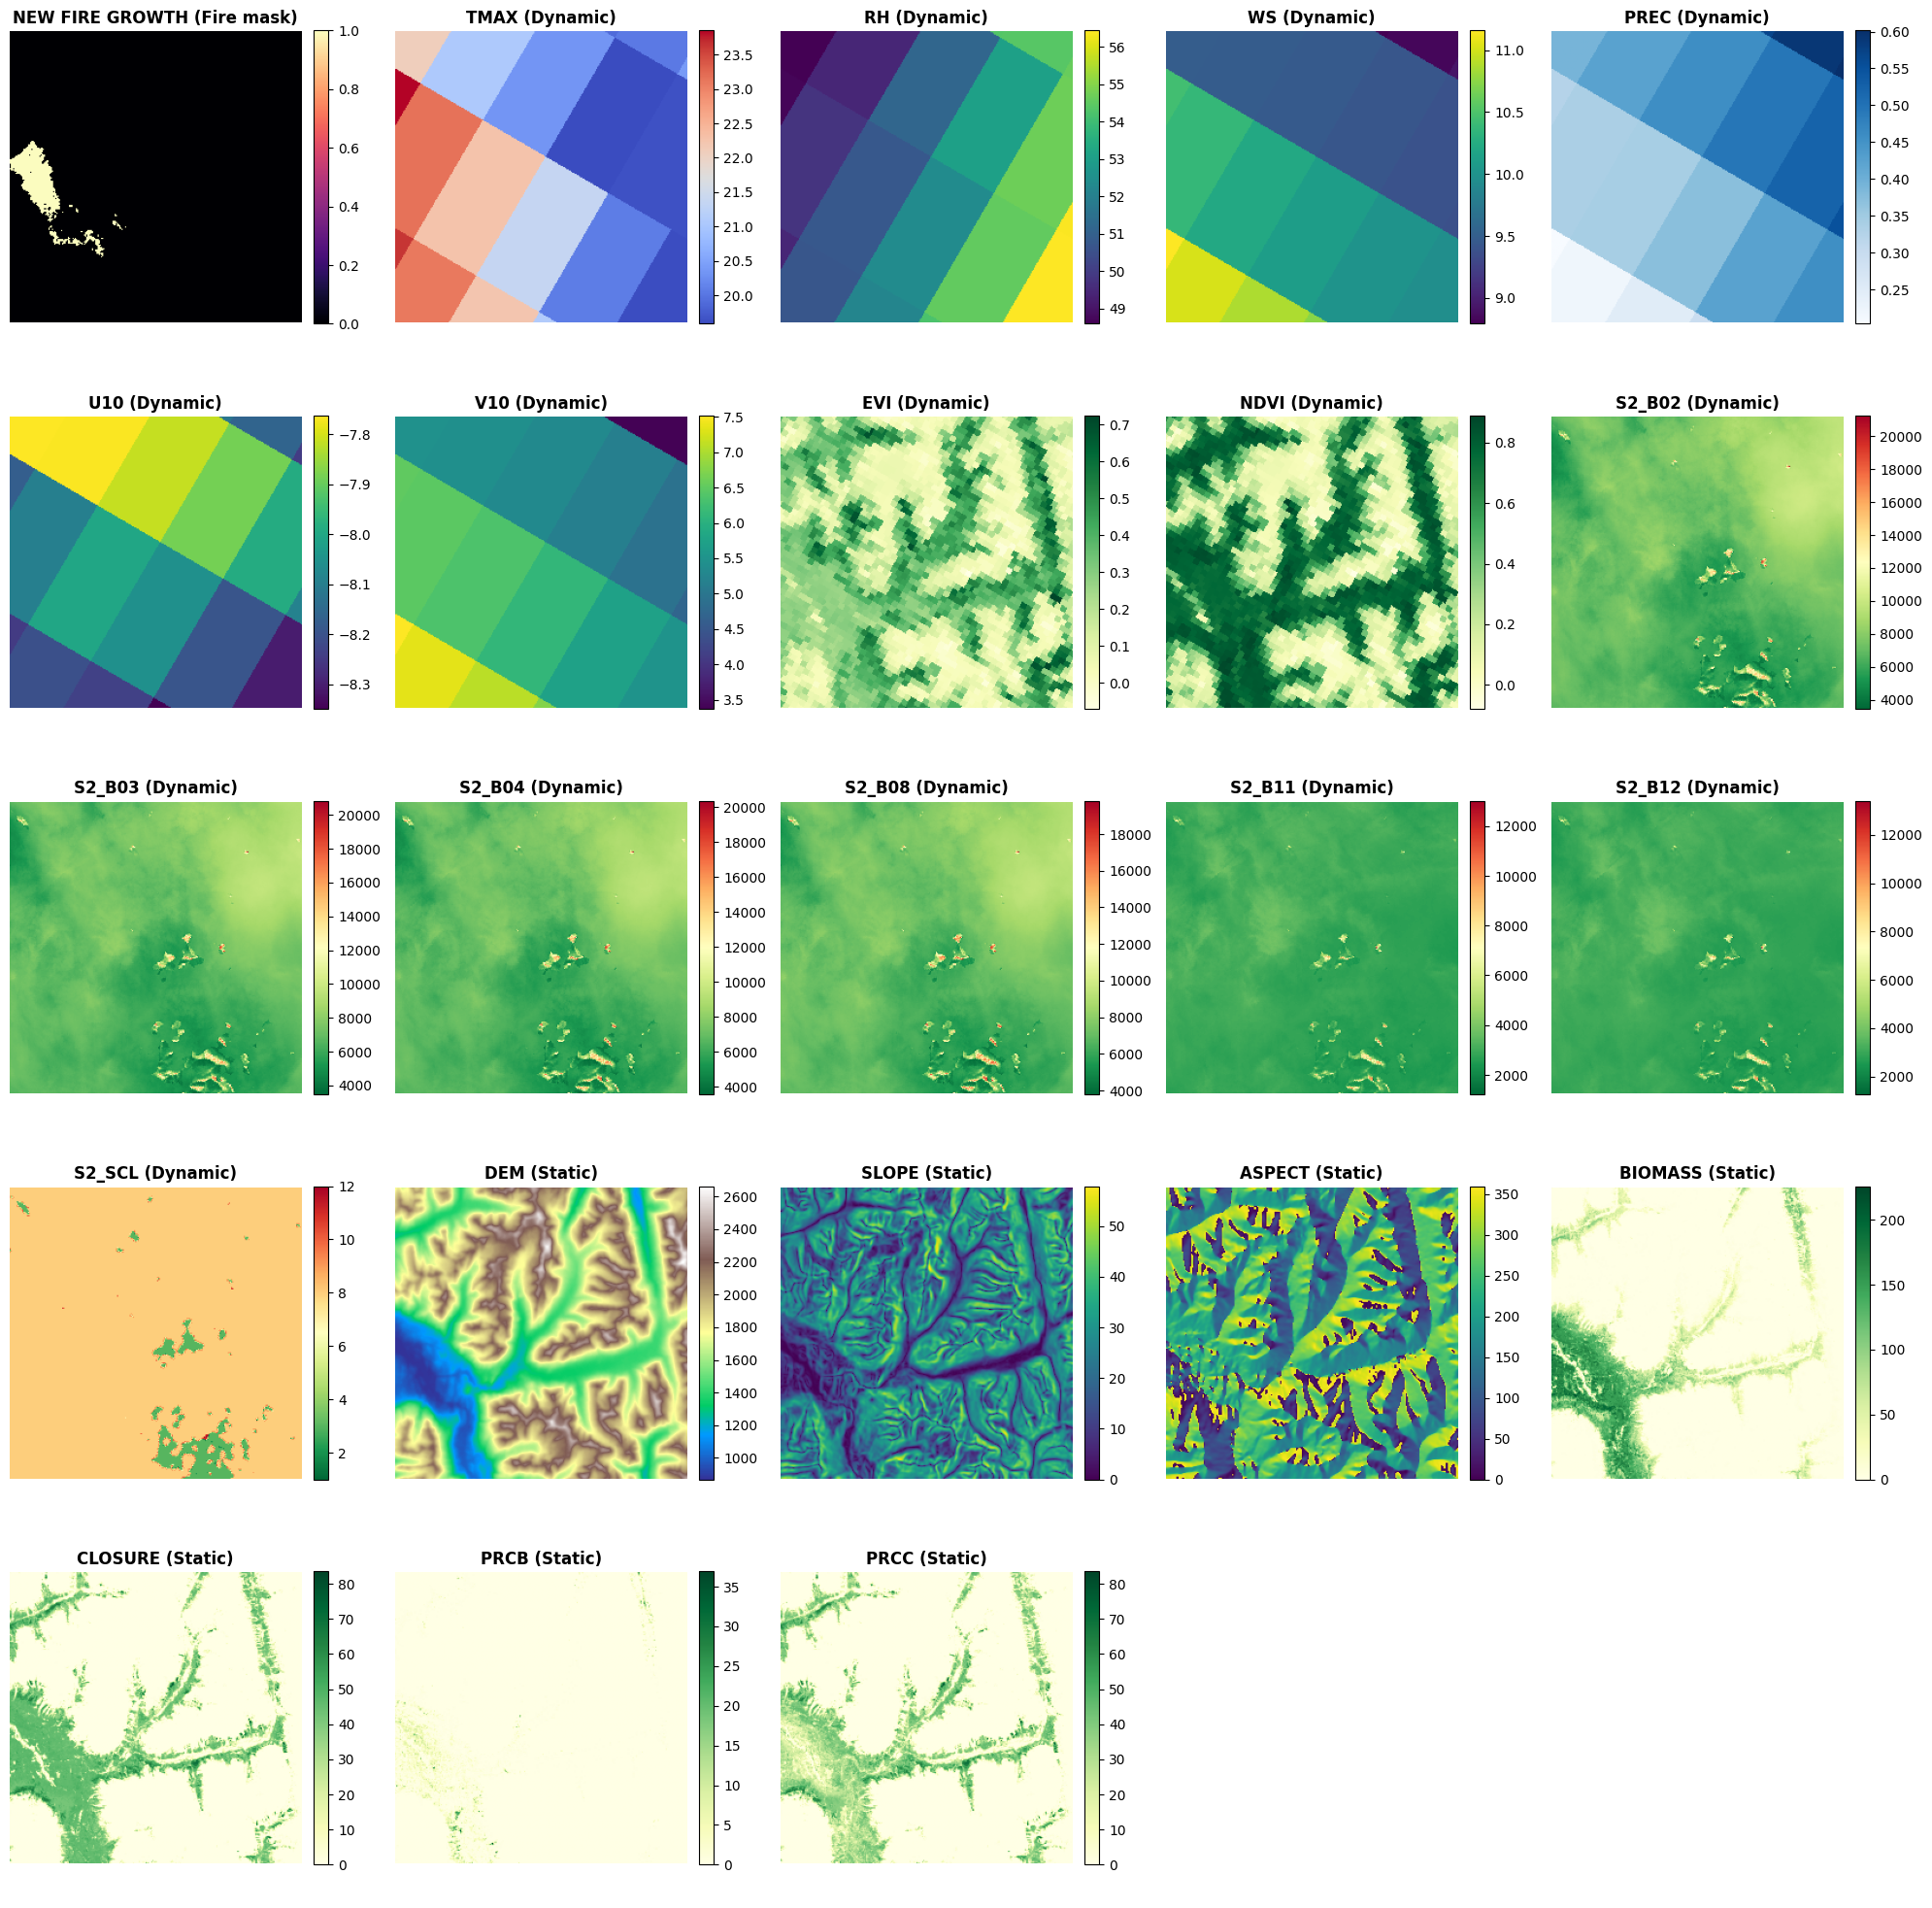

In [41]:
# --- Run the Function ---
fire_feat = 'cumuarea'

dynamic_feats = ['tmax', 'rh', 'ws', 'prec', 'u10', 'v10', 'evi', 'ndvi', 
                 's2_b02', 's2_b03', 's2_b04', 's2_b08', 's2_b11', 's2_b12', 's2_scl']

static_feats = ['dem', 'slope', 'aspect', 'biomass', 'closure', 'prcb', 'prcc']

visualize_raw_features(h5_path, tile_id, day_key, fire_feat, dynamic_feats, static_feats)

# Sample

### Sample Construction

* **Satellite Scaling:**
    * **Optical Bands:** Raw numbers are scaled by **0.0001** to convert them into standard surface reflectance values (falling within a **0** to **1** range).
    * **Scene Classification Layer (SCL):** Mask values (**0** to **11**) are scaled by **0.1**.
* **Normalization of Environmental Features:**
    * **Z-Score Normalization:** Applied to dynamic weather variables (temperature, humidity, precipitation, wind) and most static features (biomass, canopy closure, prcB, prcC, elevation, and slope).
    * **Cyclical Encoding:** The aspect feature is split into its sine and cosine components to properly preserve its continuous 360-degree rotational nature.
    * **Unprocessed:** Vegetation indices (NDVI and EVI) are left as-is, since they naturally fall within a comfortable **-1.0** to **1.0** range.
* **Fire Mask Accumulation (Up to Day T):** The model's input fire mask is created by aggregating all previously burned areas up to the current day (Day T). This provides the cumulative fire footprint as the starting state to predict the next day's new growth (Day T+1).
* **Temporal Progression Example (Days 25 vs. 26):** To illustrate this sliding window construction, we visualize two consecutive samples from the exact same fire and spatial tile. While the static topography remains identical, you can see how the dynamic variables, and accumulated fire masks evolve from Day 25 to Day 26.

### Sample Construction

In [13]:
import os
import json
import numpy as np

SAMPLES_FOLDER = F"{DATA_FOLDER}/Samples"
MAPPING_FILE = os.path.join(SAMPLES_FOLDER, "sample_mapping.json")

# Mapping dictionary (added for testing purposes)
with open(MAPPING_FILE, 'r') as f:
    mapping = json.load(f)

# Define the specific tile and the two consecutive days you want to compare
target_tile = 'tile_189_127'
day_t = 25    # e.g., Day 25
day_t_plus_1 = 26 # e.g., Day 26

sample_0_filename = None
sample_1_filename = None

# Search the mapping for the exact files
for filename, meta in mapping.items():
    if meta['tile_id'] == target_tile:
        if meta['fireday'] == day_t:
            sample_0_filename = filename
        elif meta['fireday'] == day_t_plus_1:
            sample_1_filename = filename

if not sample_0_filename or not sample_1_filename:
    print("Error: Could not find both samples in the mapping!")
else:
    print(f"Found Day {day_t}: {sample_0_filename}")
    print(f"Found Day {day_t_plus_1}: {sample_1_filename}\n")

    # 4. Construct the full paths
    sample_0_path = os.path.join(SAMPLES_FOLDER, sample_0_filename)
    sample_1_path = os.path.join(SAMPLES_FOLDER, sample_1_filename)

    # 5. Safely load and extract arrays (automatically closes the files!)
    with np.load(sample_0_path) as data_0:
        x_0, y_0, delta_t_0 = data_0['x'], data_0['y'], data_0['delta_t']
        sample_0 = {'x': x_0, 'y': y_0, 'delta_t': delta_t_0}
        
    with np.load(sample_1_path) as data_1:
        sample_1 = data_1
        x_1, y_1, delta_t_1 = data_1['x'], data_1['y'], data_1['delta_t']
        sample_1 = {'x': x_1, 'y': y_1, 'delta_t': delta_t_1}
        
    print(f"Sample 0 (Day {day_t}) X shape: {x_0.shape}")
    print(f"Sample 1 (Day {day_t_plus_1}) X shape: {x_1.shape}")

Found Day 25: sample_35.npz
Found Day 26: sample_36.npz

Sample 0 (Day 25) X shape: (25, 256, 256)
Sample 1 (Day 26) X shape: (25, 256, 256)


In [8]:
print(f"X shape: {sample_0['x'].shape} | dtype: {sample_0['x'].dtype}")
print(f"Y shape: {sample_0['y'].shape} | dtype: {sample_0['y'].dtype}")
print(f"Time gap (in days) between the day of burn and the most recent satellite image: {sample_0['delta_t']} | dtype: {sample_0['delta_t'].dtype}")

X shape: (25, 256, 256) | dtype: float32
Y shape: (256, 256) | dtype: float32
Time gap (in days) between the day of burn and the most recent satellite image: 3.0 | dtype: float32


In [9]:
fire_feat = 'cumuarea'

input_names = ['tmax', 'rh', 'ws', 'prec', 'u10', 'v10', 'evi', 'ndvi', 
              's2_b02', 's2_b03', 's2_b04', 's2_b08', 's2_b11', 's2_b12', 's2_scl',
              'dem', 'slope', 'aspect (sin)', 'aspect (cos)', 'biomass', 'closure', 'prcb', 'prcc',
              'accumulated_mask', 'scaled_accumulated_mask']

In [10]:
def visualize_numpy_sample(sample, input_names):
    """
    Loads a saved .npz sample and plots all X channels and the Y target in a grid.
    """
    x = sample['x']
    y = sample['y']
    delta_t = sample['delta_t']
    
    # Validation check
    if len(input_names) != x.shape[0]:
        print(f"Warning: You provided {len(input_names)} names, but X has {x.shape[0]} channels")
    
    # Setup the grid
    num_plots = x.shape[0] + 1 
    cols = 5
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4.2 * rows))
    axes = axes.flatten()
    
    # Plot all X (Input) Channels
    for i in range(x.shape[0]):
        ax = axes[i]
        data = x[i]
        
        # Get the feature name, fallback to index if missing
        feat_name = input_names[i] if i < len(input_names) else f"Channel {i}"

        cmap = 'viridis'
        if feat_name == 'dem': cmap = 'terrain'
        elif feat_name == 'prec': cmap = 'Blues'
        elif feat_name == 'tmax': cmap = 'coolwarm'
        elif feat_name in ['ndvi', 'evi', 'closure', 'biomass', 'prcc', 'prcb']: cmap = 'YlGn'
        elif feat_name.startswith('s2_'): cmap = 'RdYlGn_r'
        elif 'mask' in feat_name: cmap = 'magma'
        elif 'mask' in feat_name: cmap = 'RdYlGn_r'
        
        im = ax.imshow(data, cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        display_name = feat_name
        if 'mask' in feat_name.lower():
            display_name += "\n(up to day T)"
            
        ax.set_title(f"INPUT:\n{display_name}", fontsize=10, fontweight='bold')
        
        ax.axis('off')

    # Plot the Y (Target) Channel at the end
    ax_y = axes[x.shape[0]]
    im_y = ax_y.imshow(y, cmap='magma') # Red hot for new fire growth
    fig.colorbar(im_y, ax=ax_y, fraction=0.046, pad=0.04)
    
    # Highlight the target title in red
    ax_y.set_title(f"TARGET:\nFire Growth T+1", fontsize=12, fontweight='bold', color='red')
    ax_y.axis('off')
    
    # Hide empty subplots
    for j in range(x.shape[0] + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

## Day 25 of the fire to predict day 26

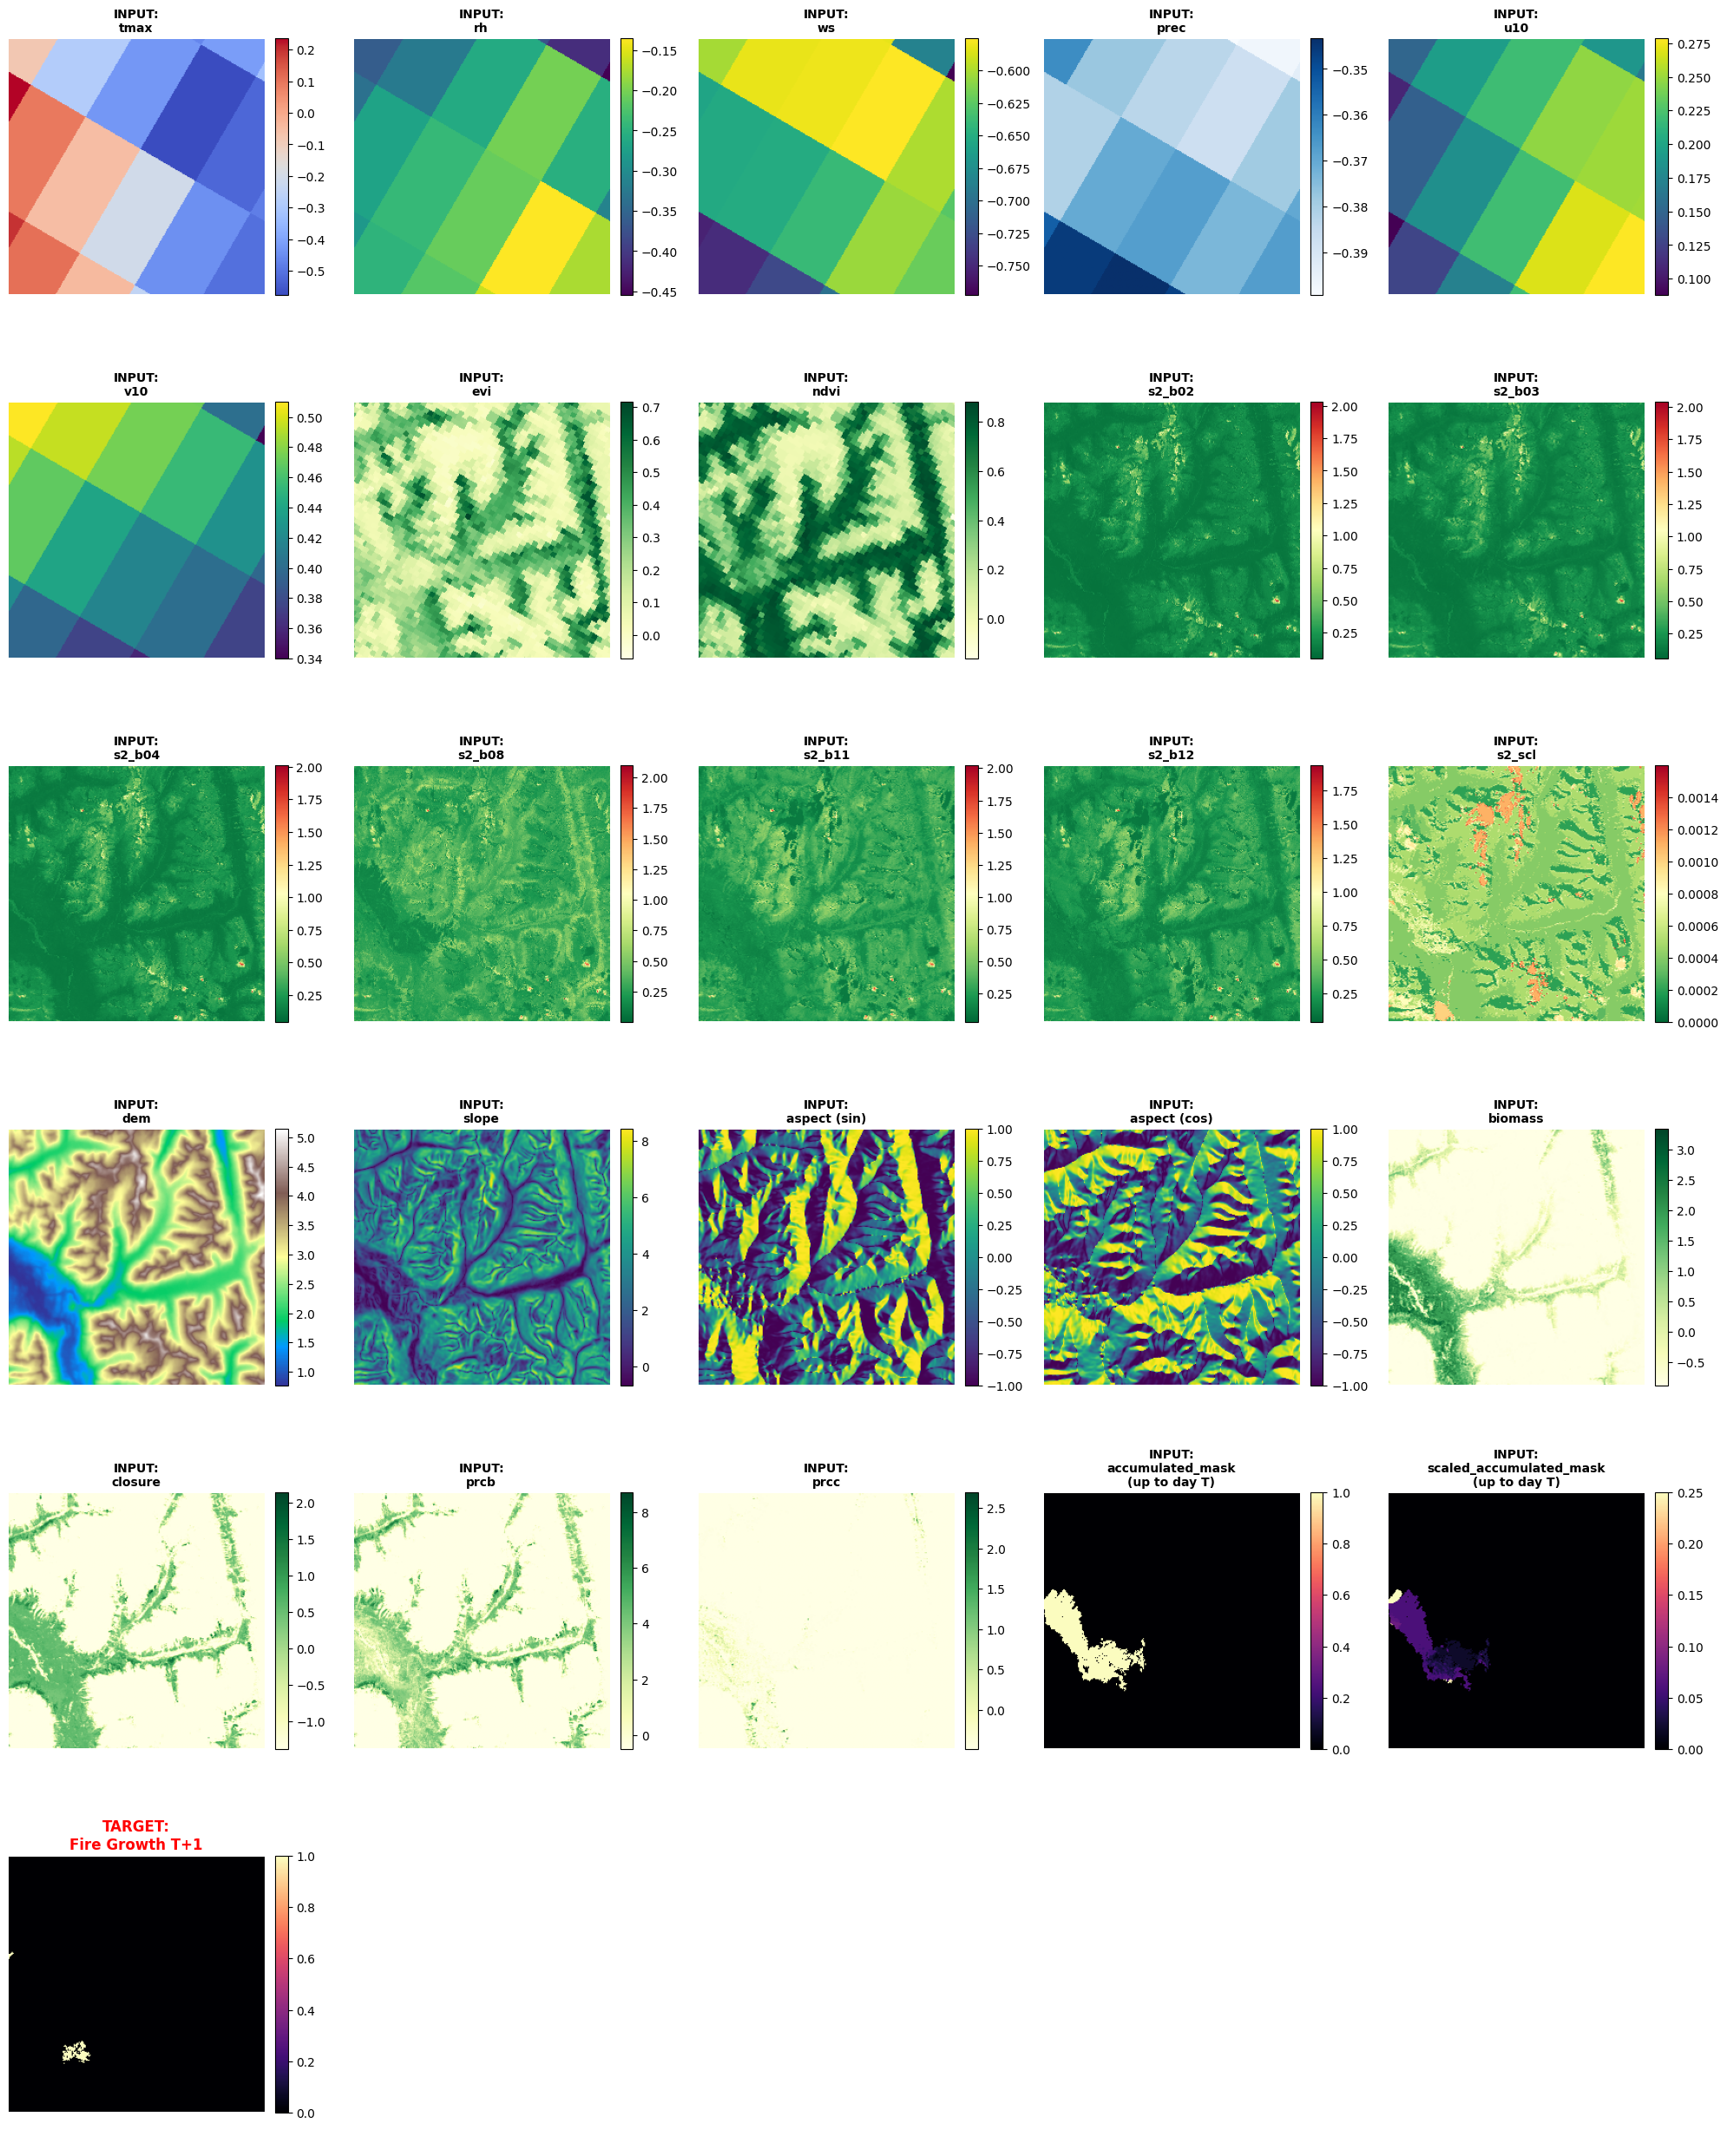

In [11]:
visualize_numpy_sample(sample_0, input_names)

## Day 26 of the fire to predict day 27

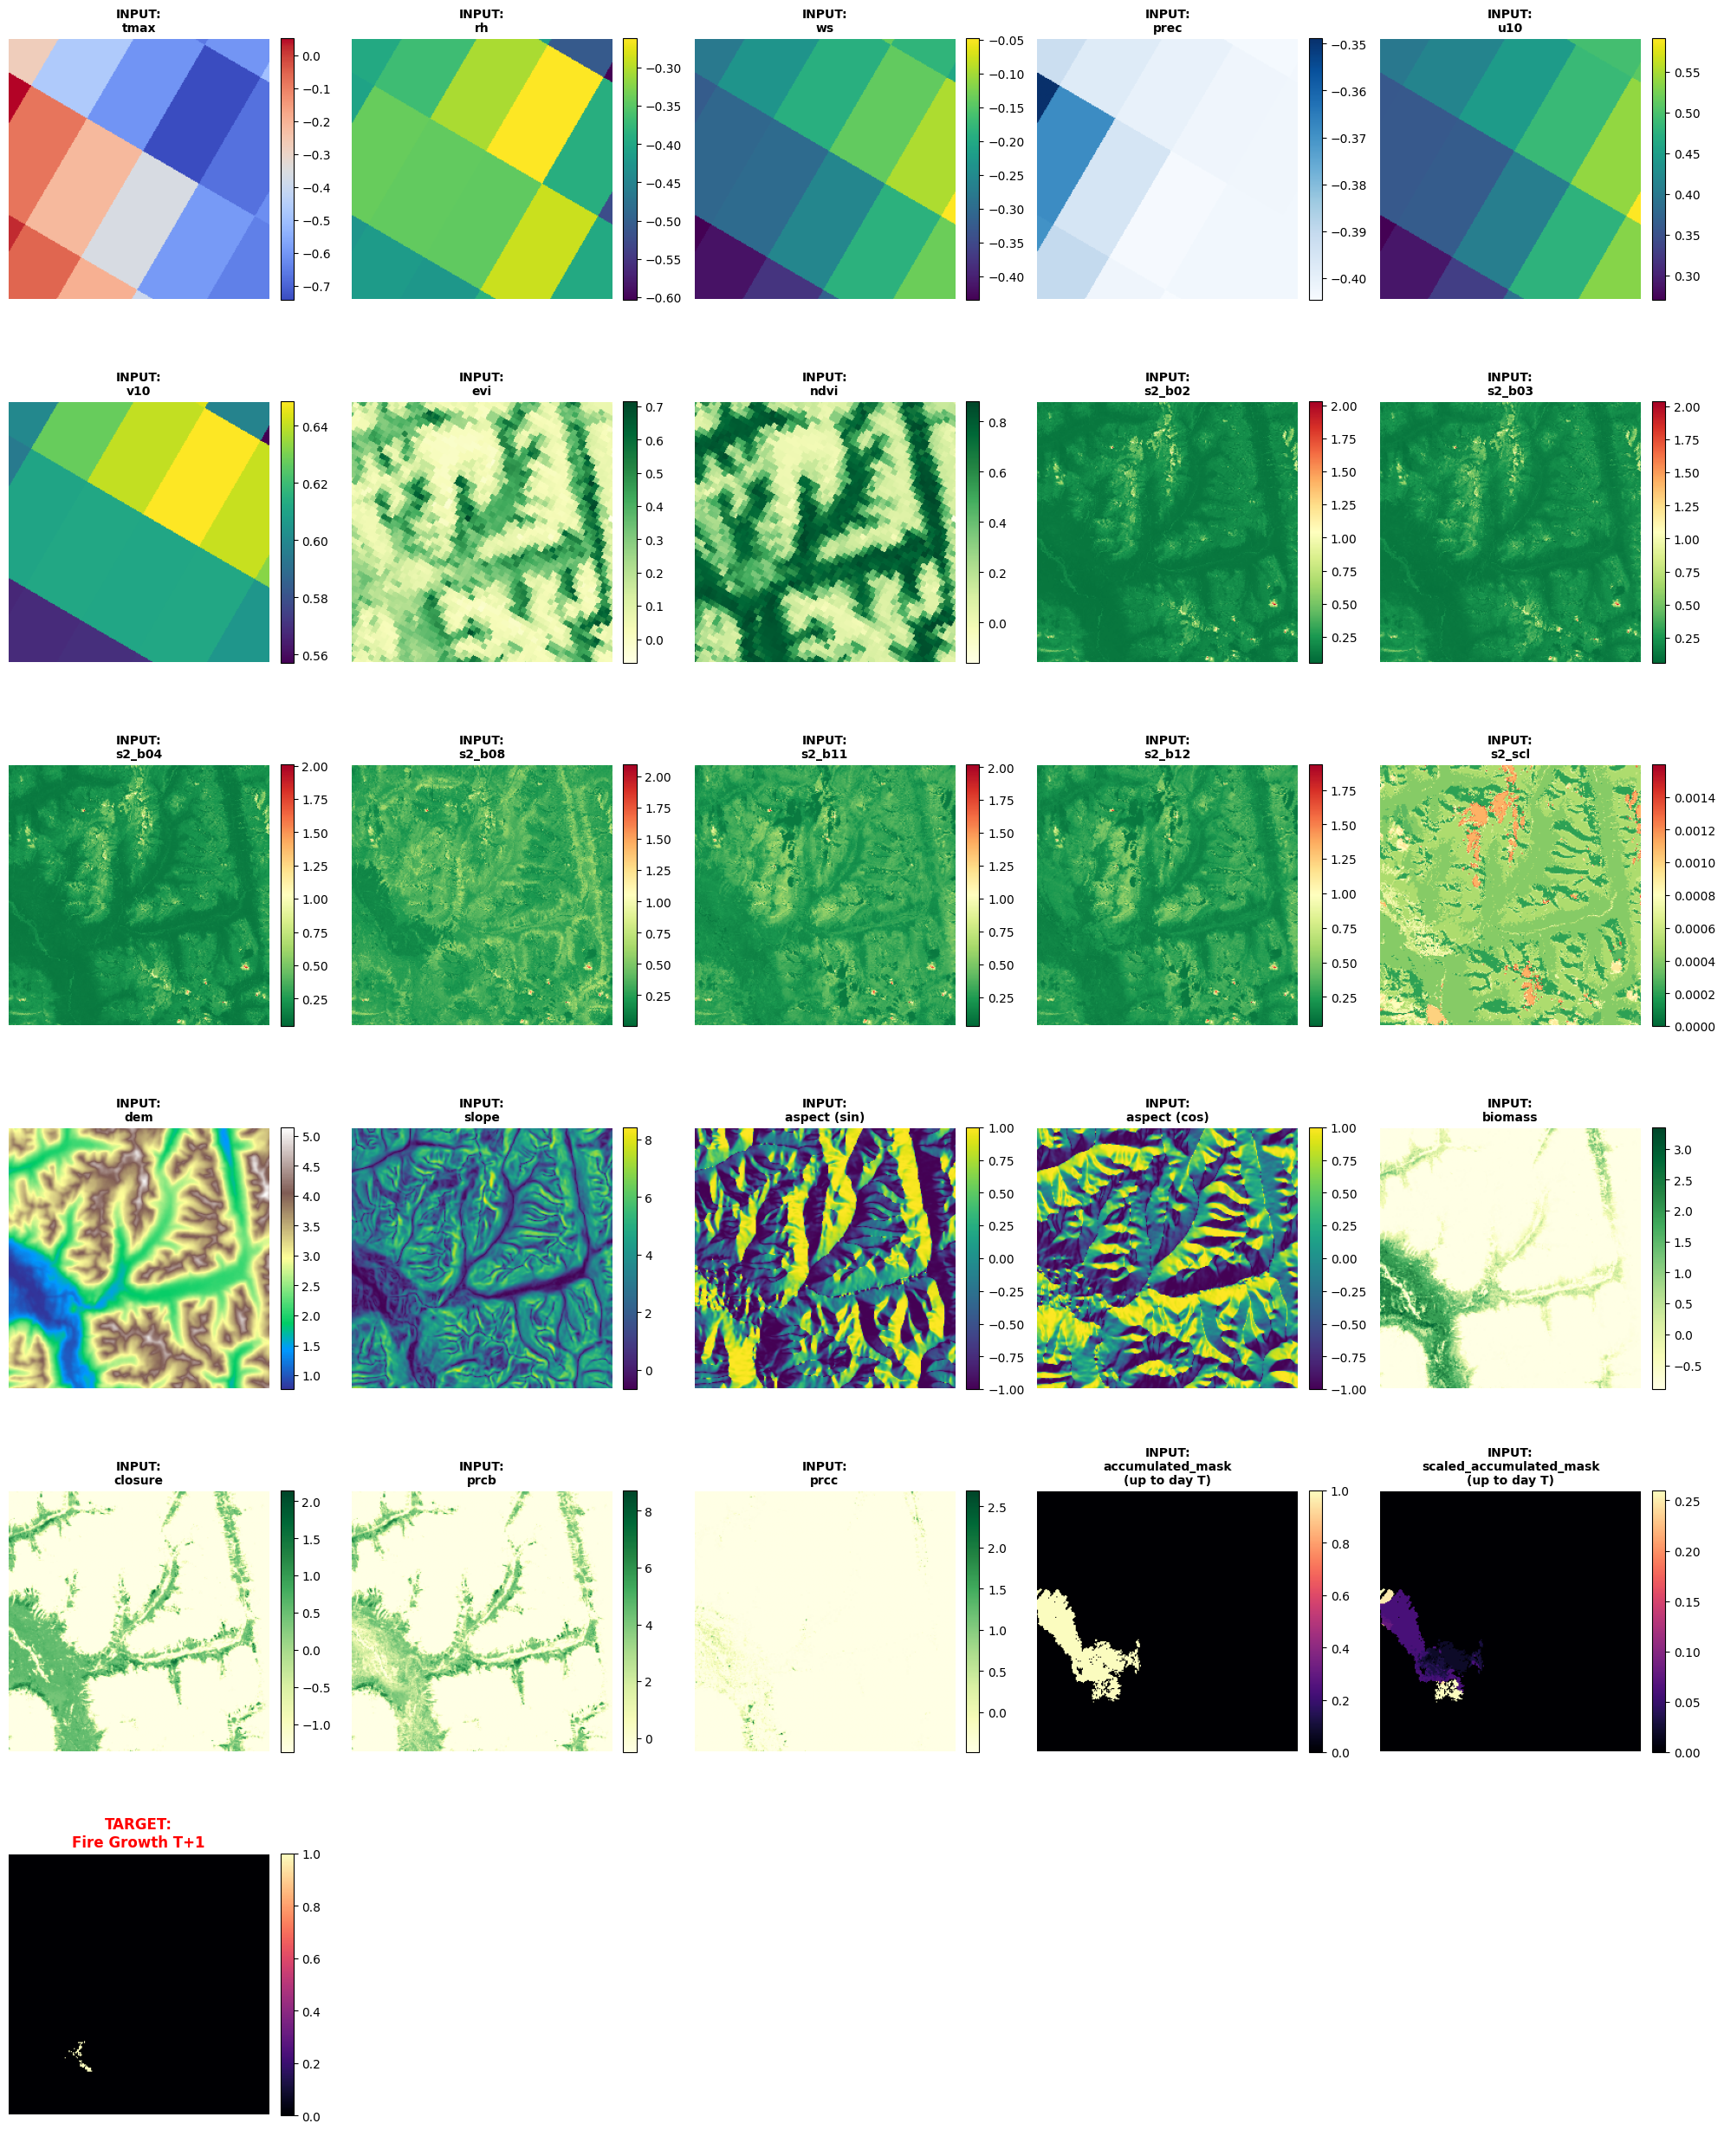

In [14]:
visualize_numpy_sample(sample_1, input_names)

In [ ]:
# Range of the values